In [ ]:
pip install gwaslab 


Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [2]:
import gwaslab as gl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import gzip

file_path = "../data/susie/gwas/21001_raw.gwas.imputed_v3.both_sexes.tsv.bgz"
with gzip.open(file_path, 'rt') as f:
    df = pd.read_csv(f, sep='\t') 


In [ ]:
df.head()


,variant,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,pval
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342


In [ ]:
df['CHR'] = df['variant'].str.split(':').str[0]
df['POS'] = df['variant'].str.split(':').str[1]
df['A2']=df['variant'].str.split(':').str[2]
df['A1']=df['variant'].str.split(':').str[3]



In [ ]:
df.shape

(13791467, 15)

In [ ]:
df=df.rename(columns={'variant':'SNPID', 'pval':'P'})
minor_df=df[df['minor_AF'] > 0.05]
minor_df = minor_df[~minor_df['SNPID'].str.startswith('X:')]
minor_df.head()



,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS,A2,A1
4,1:692794:CA:C,C,0.110590,False,359983,79621.1,2179000.0,-0.016436,0.019585,-0.839228,0.401342,1,692794,CA,C
5,1:693731:A:G,G,0.115767,False,359983,83348.0,2281760.0,-0.004255,0.018507,-0.229918,0.818155,1,693731,A,G
6,1:707522:G:C,C,0.097255,False,359983,70020.6,1916410.0,-0.010428,0.020804,-0.501258,0.616190,1,707522,G,C
9,1:730087:T:C,C,0.056424,False,359983,40623.1,1110650.0,-0.047388,0.025783,-1.837930,0.066074,1,730087,T,C
10,1:731718:T:C,C,0.121670,False,359983,87598.4,2397990.0,-0.005842,0.017552,-0.332853,0.739246,1,731718,T,C


In [ ]:
# processed_df_csv=minor_df.to_csv("processed_df.csv", sep=" ", index=False)


Processed File

In [ ]:
import pandas as pd 
df = pd.read_csv("../data/susie/chr_16/processed_raw_data/processed_df.csv", delim_whitespace=True)

/tmp/ipykernel_4006330/1352686489.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("processed_df.csv", delim_whitespace=True)


In [ ]:
df.rename(columns={
    'SNPID': 'SNP',
    'A1': 'A1',
    'A2': 'A2',
    'minor_AF': 'freq',
    'beta': 'b',
    'se': 'se',
    'P': 'p',
    'n_complete_samples': 'N'
}, inplace=True)


extracted_columns = ['SNP', 'A1', 'A2', 'freq', 'b', 'se', 'p', 'N']
df_extracted = df[extracted_columns]
df_extracted.head()
# cojo_df=df_extracted.to_csv("../data/susie/reformated_data_for_cojo/cojo_extracted_file.csv", sep=" ", index=False)


53767042

In [ ]:
df_extracted.head()

,SNP,A1,A2,freq,b,se,p,N
0,1:692794:CA:C,C,CA,0.110590,-0.016436,0.019585,0.401342,359983
1,1:693731:A:G,G,A,0.115767,-0.004255,0.018507,0.818155,359983
2,1:707522:G:C,C,G,0.097255,-0.010428,0.020804,0.616190,359983
3,1:730087:T:C,C,T,0.056424,-0.047388,0.025783,0.066074,359983
4,1:731718:T:C,C,T,0.121670,-0.005842,0.017552,0.739246,359983


Tested cojo snps

RUN COJO

gcta64 --bfile plot_chr16_eur/chr16_eur --chr 16 --maf 0.05 --cojo-file ../cojo_extracted_file.csv  --cojo-slct --out tes_chr16

icog-bioai@dl:/mnt/hdd_2/rediet/hypothesis-generation-demo/notebooks/gcta-1.94.3-linux-kernel-3-x86_64$ gcta64 --bfile plot_chr16_eur/chr16_eur --chr 16 --maf 0.05 --cojo-file ../cojo_extracted_file.csv  --cojo-slct --out tes_chr16
*******************************************************************
* Genome-wide Complex Trait Analysis (GCTA)
* version v1.94.1 Linux
* Built at Dec 16 2024 16:35:13, by GCC 8.3
* (C) 2010-present, Yang Lab, Westlake University
* Please report bugs to Jian Yang <jian.yang@westlake.edu.cn>
*******************************************************************
Analysis started at 07:20:46 PST on Mon Feb 17 2025.
Hostname: dl

Accepted options:
--bfile plot_chr16_eur/chr16_eur
--chr 16
--maf 0.05
--cojo-file ../cojo_extracted_file.csv
--cojo-slct
--out tes_chr16


Reading PLINK FAM file from [plot_chr16_eur/chr16_eur.fam].
503 individuals to be included from [plot_chr16_eur/chr16_eur.fam].
Reading PLINK BIM file from [plot_chr16_eur/chr16_eur.bim].
2697949 SNPs to be included from [plot_chr16_eur/chr16_eur.bim].
Warning: Duplicated SNP ID "16:12018309:T:<CN0>" has been changed to "16:12018309:T:<CN0>_522327"
.2697949 SNPs on chromosome 16 are included in the analysis.
Reading PLINK BED file from [plot_chr16_eur/chr16_eur.bed] in SNP-major format ...
Genotype data for 503 individuals and 2697949 SNPs to be included from [plot_chr16_eur/chr16_eur.bed].
Calculating allele frequencies ...
Filtering SNPs with MAF > 0.05 ...
After filtering SNPs with MAF > 0.05, there are 213642 SNPs (2484307 SNPs with MAF < 0.05).

Reading GWAS summary-level statistics from [../cojo_extracted_file.csv] ...
GWAS summary statistics of 6746855 SNPs read from [../cojo_extracted_file.csv].
Phenotypic variance estimated from summary statistics of all 6746855 SNPs: 22.4472 (variance of logit for case-control studies).
Matching the GWAS meta-analysis results to the genotype data ...
Warning: can't match the reference alleles of 24 SNPs to those in the genotype data. These SNPs have been saved in [tes_chr16.badsnps].
36864 SNP(s) have large difference of allele frequency between the GWAS summary data and the reference sample. These SNPs have been saved in [tes_chr16.freq.badsnps].
160362 SNPs are matched to the genotype data.
Calculating the variance of SNP genotypes ...

Performing stepwise model selection on 160362 SNPs to select association signals ... (p cutoff = 5e-08; collinearity cutoff = 0.9)
(Assuming complete linkage equilibrium between SNPs which are more than 10Mb away from each other)
5 associated SNPs have been selected.
10 associated SNPs have been selected.
15 associated SNPs have been selected.
20 associated SNPs have been selected.
25 associated SNPs have been selected.
30 associated SNPs have been selected.
35 associated SNPs have been selected.
40 associated SNPs have been selected.
45 associated SNPs have been selected.
50 associated SNPs have been selected.
55 associated SNPs have been selected.
60 associated SNPs have been selected.
65 associated SNPs have been selected.
70 associated SNPs have been selected.
75 associated SNPs have been selected.
80 associated SNPs have been selected.
85 associated SNPs have been selected.
90 associated SNPs have been selected.
95 associated SNPs have been selected.
100 associated SNPs have been selected.
105 associated SNPs have been selected.
110 associated SNPs have been selected.
115 associated SNPs have been selected.
120 associated SNPs have been selected.
125 associated SNPs have been selected.
130 associated SNPs have been selected.
135 associated SNPs have been selected.
140 associated SNPs have been selected.
145 associated SNPs have been selected.
150 associated SNPs have been selected.
155 associated SNPs have been selected.
160 associated SNPs have been selected.
165 associated SNPs have been selected.
170 associated SNPs have been selected.
175 associated SNPs have been selected.
180 associated SNPs have been selected.
Finally, 180 associated SNPs are selected.
Performing joint analysis on all the 180 selected signals ...
Saving the 180 independent signals to [tes_chr16.jma.cojo] ...
Saving the LD structure of 180 independent signals to [tes_chr16.ldr.cojo] ...
Saving the conditional analysis results of 74260 remaining SNPs to [tes_chr16.cma.cojo] ...
(2 SNPs eliminated by backward selection and 85920 SNPs filtered by collinearity test are not included in the output)

Analysis finished at 07:34:27 PST on Mon Feb 17 2025
Overall computational time: 13 minutes 40 sec.

In [ ]:
import pandas as pd
df_tested_cojo_snps = pd.read_csv("../data/susie/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)

In [ ]:
df_tested_cojo_snps.head()

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r,p_original
0,16,16:209764:G:C,209764,C,0.173538,-0.021170,0.014718,1.503410e-01,361237,0.168986,-1.406950,0.018339,0.000000e+00,0.070327,1.503410e-01
1,16,16:406427:G:C,406427,C,0.355430,-0.080681,0.011680,4.931170e-12,359053,0.310139,-1.574420,0.016174,0.000000e+00,0.045560,4.938870e-12
2,16,16:782397:C:T,782397,T,0.238811,0.012140,0.013152,3.559810e-01,356967,0.218688,1.313190,0.016386,0.000000e+00,0.084925,3.559800e-01
3,16,16:931605:G:C,931605,C,0.074670,-0.048957,0.021191,2.087260e-02,361723,0.073559,-2.931640,0.030100,0.000000e+00,0.016078,2.087340e-02
4,16,16:1063319:G:A,1063319,A,0.077376,-0.010060,0.020961,6.312490e-01,357842,0.067594,0.136596,0.022845,2.241920e-09,0.046316,6.312480e-01


In [ ]:
# df_tested_cojo_snps["SNP"].to_csv("../data/susie/chr_16/snplist/cojo_sig_locus.snplist.txt",sep=" ",index=None,header=None)


In [ ]:
!plink \
  --bfile "../data/susie/chr_16/plink_b_files/chr16_eur" \
  --keep-allele-order \
  --r square \
  --extract ../data/susie/snplist/cojo_sig_locus.snplist.txt \
  --out ../data/susie/ld/sig_locus_mt

!plink \
  --bfile "../data/susie/chr_16/plink_b_files/chr16_eur" \
  --keep-allele-order \
  --r2 square \
  --extract ../data/susie/snplist/cojo_sig_locus.snplist.txt \
  --out ../data/susie/ld/sig_locus_mt_r2

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../data/plot_ld/cojo_sig_locus_mt.log.
Options in effect:
  --bfile ../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/plot_chr16_eur/chr16_eur
  --extract ../data/snplist/cojo_sig_locus.snplist.txt
  --keep-allele-order
  --out ../data/plot_ld/cojo_sig_locus_mt
  --r square

257418 MB RAM detected; reserving 128709 MB for main workspace.
2697949 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../data/plot_ld/cojo_sig_locus_mt.nosex .
--extract: 180 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 1011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859606162636465666768697071727

In [6]:

from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import rpy2.robjects.pandas2ri as pandas2ri
numpy2ri.activate()
pandas2ri.activate()

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/home/icog-bioai/jdk-11.0.2/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/home/icog-bioai/jdk-11.0.2/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


In [7]:
susieR = importr('susieR')

In [ ]:

ld = pd.read_csv("../data/susie/ld/sig_locus_mt.ld", sep="\t", header=None)
R_df = ld.values
ld2 = pd.read_csv("../data/susie/ld/sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(180, 180)

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

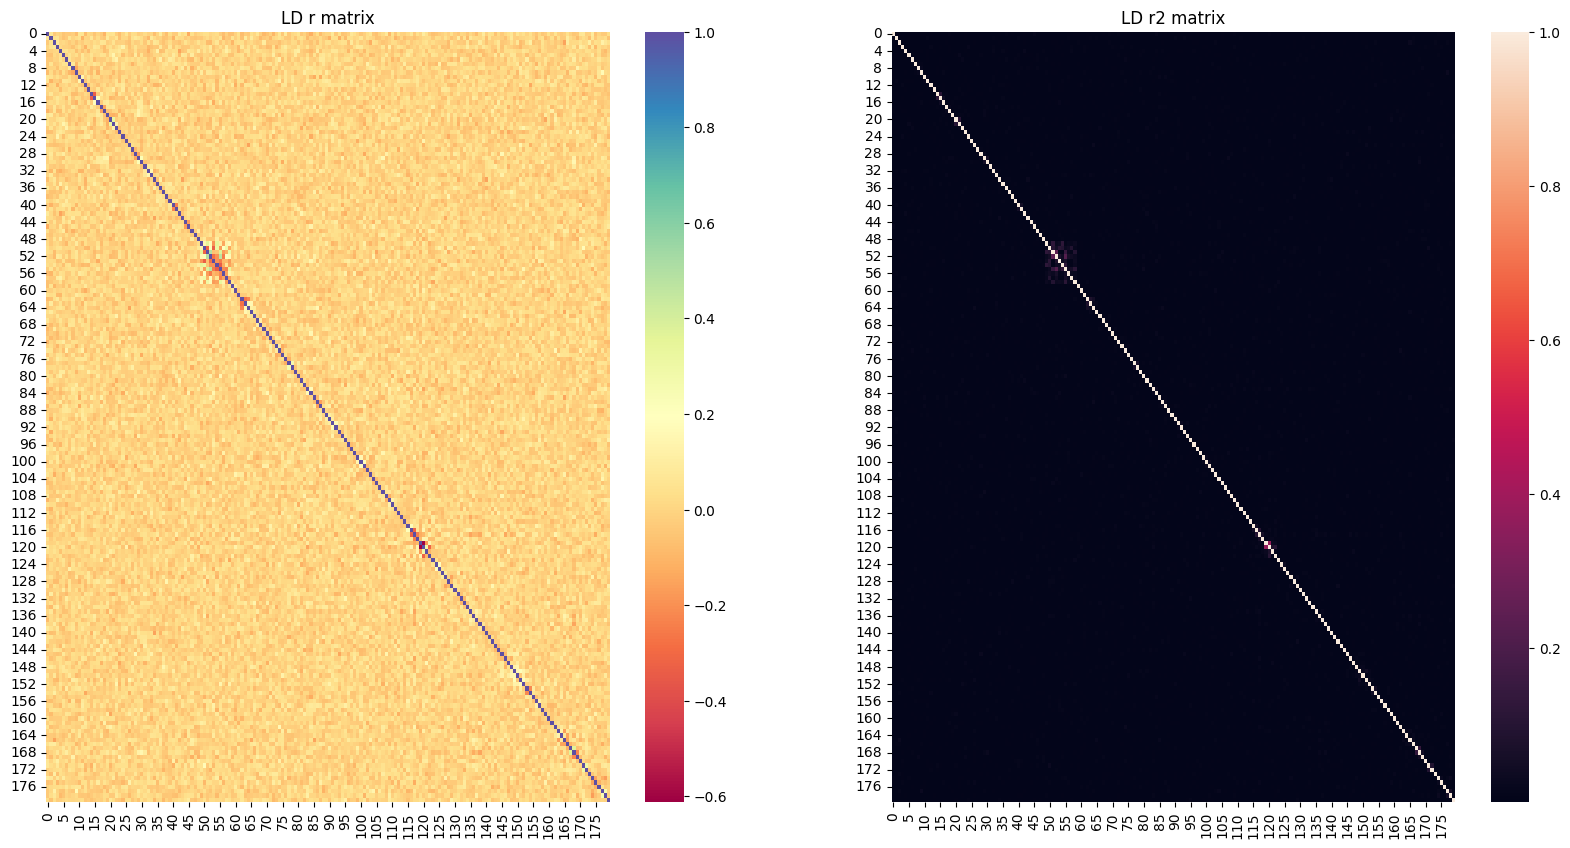

In [9]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=R_df,cmap="Spectral",ax=ax[0])
sns.heatmap(data=R_df2,ax=ax[1])
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")

In [ ]:
df_tested_cojo_snps = pd.read_csv("../data/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)

/tmp/ipykernel_561673/311340159.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_tested_cojo_snps = pd.read_csv("../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)


In [4]:
df_tested_cojo_snps.head(3)

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r
0,16,16:209764:G:C,209764,C,0.173538,-0.021170,0.014718,1.503410e-01,361237,0.168986,-1.40695,0.018339,0.0,0.070327
1,16,16:406427:G:C,406427,C,0.355430,-0.080681,0.011680,4.931170e-12,359053,0.310139,-1.57442,0.016174,0.0,0.045560
2,16,16:782397:C:T,782397,T,0.238811,0.012140,0.013152,3.559810e-01,356967,0.218688,1.31319,0.016386,0.0,0.084925


In [10]:
ro.r('set.seed(123)')
fit = susieR.susie_rss(
    bhat = df_tested_cojo_snps["b"].values.reshape(len(R_df), 1),
    shat = df_tested_cojo_snps["se"].values.reshape(len(R_df), 1),
    R = R_df,
    L = 10,
    n = 503
)

In [11]:

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)
print(credible_sets)

$cs
$cs$L1
[1] 118

$cs$L2
[1] 97

$cs$L3
[1] 96

$cs$L4
[1] 98

$cs$L5
[1] 95

$cs$L6
[1] 18

$cs$L7
[1] 105

$cs$L8
[1] 21

$cs$L9
[1] 147


$purity
   min.abs.corr mean.abs.corr median.abs.corr
L1            1             1               1
L2            1             1               1
L3            1             1               1
L4            1             1               1
L5            1             1               1
L6            1             1               1
L7            1             1               1
L8            1             1               1
L9            1             1               1

$cs_index
[1] 1 2 3 4 5 6 7 8 9

$coverage
[1] 1.0000000 1.0000000 1.0000000 0.9999990 0.9999864 1.0000000 0.9999995
[8] 0.9995016 0.9998708

$requested_coverage
[1] 0.95




53767042

In [12]:

df_tested_cojo_snps["cs"] = 0
n_cs = len(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df)[0])
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]

for i in range(n_cs):
    cs_index = credible_sets[i]
    df_tested_cojo_snps.loc[np.array(cs_index)-1, "cs"] = i + 1

df_tested_cojo_snps["pip"] = np.array(susieR.susie_get_pip(fit))
df_tested_cojo_snps

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r,cs,pip
0,16,16:209764:G:C,209764,C,0.173538,-0.021170,0.014718,1.503410e-01,361237,0.168986,-1.406950,0.018339,0.000000e+00,0.070327,0,3.563816e-14
1,16,16:406427:G:C,406427,C,0.355430,-0.080681,0.011680,4.931170e-12,359053,0.310139,-1.574420,0.016174,0.000000e+00,0.045560,0,3.657974e-11
2,16,16:782397:C:T,782397,T,0.238811,0.012140,0.013152,3.559810e-01,356967,0.218688,1.313190,0.016386,0.000000e+00,0.084925,0,5.213607e-13
3,16,16:931605:G:C,931605,C,0.074670,-0.048957,0.021191,2.087260e-02,361723,0.073559,-2.931640,0.030100,0.000000e+00,0.016078,0,1.743050e-13
4,16,16:1063319:G:A,1063319,A,0.077376,-0.010060,0.020961,6.312490e-01,357842,0.067594,0.136596,0.022845,2.241920e-09,0.046316,0,1.122435e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,16,16:69942368:T:TA,69942368,TA,0.065122,-0.041314,0.022852,7.062120e-02,353026,0.058648,-1.255260,0.025694,0.000000e+00,-0.120466,0,4.063416e-14
176,16,16:70368909:G:A,70368909,A,0.116714,-0.090113,0.017355,2.077710e-07,361420,0.112326,-0.969185,0.019050,0.000000e+00,-0.057807,0,6.781131e-06
177,16,16:72194325:T:C,72194325,C,0.478183,0.047949,0.011202,1.866400e-05,358420,0.514911,0.074413,0.011844,3.327300e-10,-0.249064,0,2.196351e-08
178,16,16:72447253:A:G,72447253,G,0.077731,-0.082924,0.020890,7.199410e-05,358747,0.069583,-0.491101,0.022469,6.665490e-106,-0.012923,0,1.139970e-09


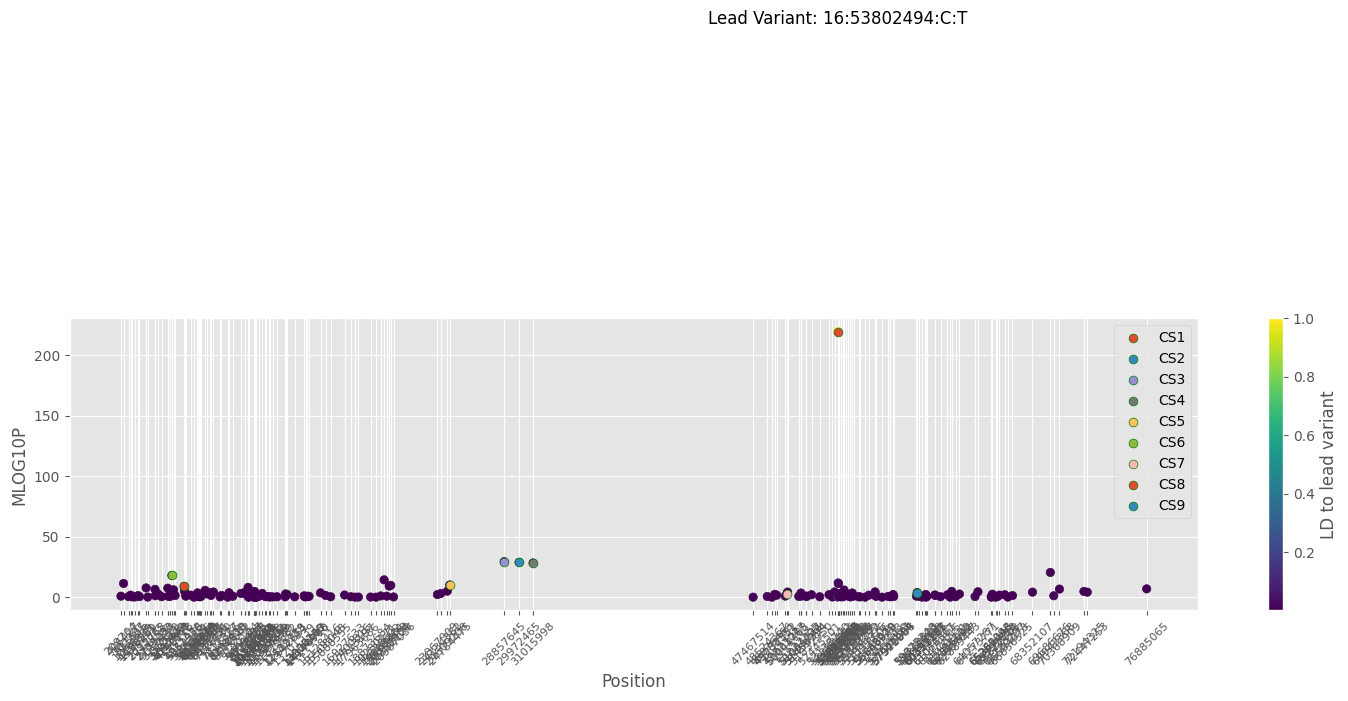

In [23]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))
col_to_plot = "MLOG10P"
df_tested_cojo_snps[col_to_plot] = -np.log10(df_tested_cojo_snps["p"])


p=ax.scatter(df_tested_cojo_snps["bp"], df_tested_cojo_snps[col_to_plot], c=ld2[df_tested_cojo_snps["p"].idxmin()])


lead_x, lead_y = df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), "bp"], df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df_tested_cojo_snps.loc[df_tested_cojo_snps['p'].idxmin(), 'SNP']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)



for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df_tested_cojo_snps.loc[np.array(cs_index)-1, "bp"]
    y = df_tested_cojo_snps.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")



plt.colorbar(p, label="LD to lead variant")

ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)

x_positions = df_tested_cojo_snps["bp"].values
ax.set_xticks(x_positions)
ax.set_xticklabels(x_positions, rotation=45, fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

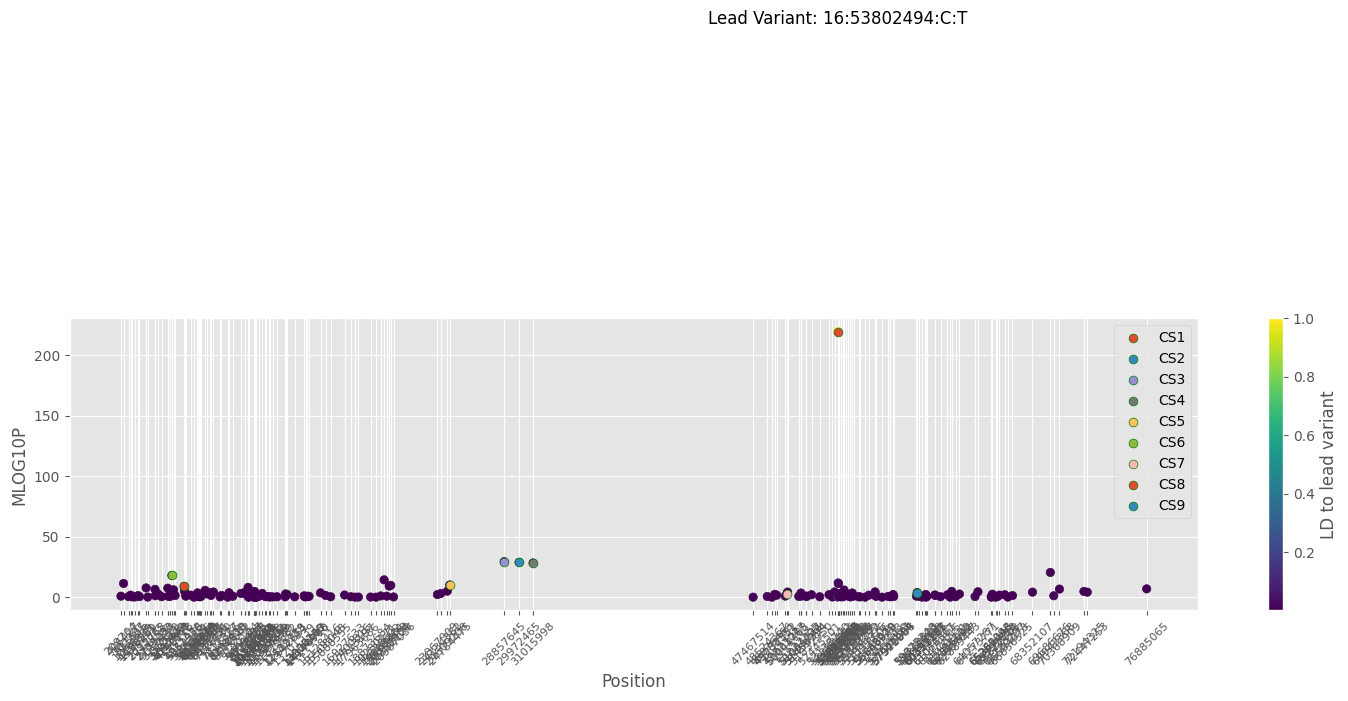

In [13]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "MLOG10P"
df_tested_cojo_snps[col_to_plot] = -np.log10(df_tested_cojo_snps["p"])


p = ax.scatter(df_tested_cojo_snps["bp"], df_tested_cojo_snps[col_to_plot], c=ld2[df_tested_cojo_snps["p"].idxmin()])


lead_x, lead_y = df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), "bp"], df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df_tested_cojo_snps.loc[df_tested_cojo_snps['p'].idxmin(), 'SNP']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)


for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df_tested_cojo_snps.loc[np.array(cs_index)-1, "bp"]
    y = df_tested_cojo_snps.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")

plt.colorbar(p, label="LD to lead variant")

ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)

x_positions = df_tested_cojo_snps["bp"].values
ax.set_xticks(x_positions)
ax.set_xticklabels(x_positions, rotation=45, fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()


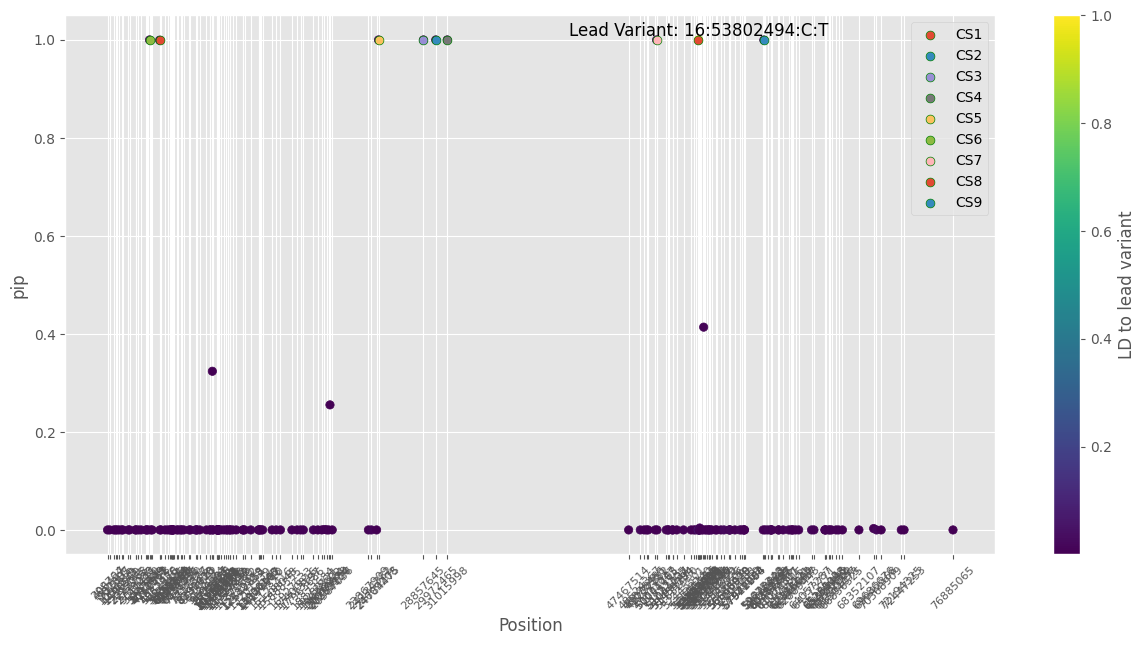

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "pip"
p = ax.scatter(df_tested_cojo_snps["bp"], df_tested_cojo_snps[col_to_plot], c=ld2[df_tested_cojo_snps["p"].idxmin()])


lead_x, lead_y = df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), "bp"], df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df_tested_cojo_snps.loc[df_tested_cojo_snps['p'].idxmin(), 'SNP']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)


for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df_tested_cojo_snps.loc[np.array(cs_index)-1, "bp"]
    y = df_tested_cojo_snps.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)

x_positions = df_tested_cojo_snps["bp"].values
ax.set_xticks(x_positions)
ax.set_xticklabels(x_positions, rotation=45, fontsize=8)


plt.legend()
plt.show()

rs141085
16:53767042 (GRCh38)
16:53800954 (GRCh37)

In [20]:
cs_index = np.array(credible_sets[0])
for i in range(1, n_cs):
    cs_index = np.concatenate((cs_index, np.array(credible_sets[i])), axis=0)
# cs_index = np.array(cs_index).flatten()
credible_snps = df_tested_cojo_snps.loc[cs_index - 1, :]



16:53802494:C:T 
rs11642015

In [24]:
print(credible_snps)

     Chr                             SNP        bp              refA  \
117   16                 16:53802494:C:T  53802494                 T   
96    16                16:29972465:C:CA  29972465                CA   
95    16                 16:28857645:A:G  28857645                 G   
97    16                16:31015998:TA:T  31015998                 T   
94    16                 16:24784475:C:T  24784475                 T   
17    16                  16:4017567:T:A   4017567                 A   
104   16  16:50001765:G:GTACCACCAGCGAAGC  50001765  GTACCACCAGCGAAGC   
20    16                  16:4932470:G:A   4932470                 A   
146   16                 16:59728623:C:T  59728623                 T   

         freq         b        se              p       n  freq_geno        bJ  \
117  0.402018  0.359699  0.011353  2.721410e-220  361202   0.432406  3.731550   
96   0.416972  0.133687  0.011854   1.692900e-29  328416   0.400596  0.084194   
95   0.405474  0.129342  0.011357   

In [ ]:
credible_snps.to_csv("../data/susie/credible_sets/credible_sets.txt", index=False, header=None)